## **Pipeline for Enviromental Audio Classification using Custom CNN Pipeline**

In [2]:
# Import Neccesary Libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as spec
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from speechbrain.lobes.models.beats import BEATs
import torchaudio
import copy
from tqdm import tqdm
from google.colab import drive

# Mount Drive To Properly Save Model Weights
drive.mount('/content/drive')

# Check and set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if device.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


Mounted at /content/drive
PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : NVIDIA A100-SXM4-40GB


In [3]:
# Import dataset from HuggingFace
from datasets import load_dataset
audio_dataset = load_dataset("ashraq/esc50")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [16]:
# ESC-50 has 5 official pre-assigned folds, no manual splitting needed
total_set = audio_dataset["train"]
print(f"Total samples: {len(total_set)}")
print(f"Folds available: {sorted(set(total_set['fold']))}")

esc50_labels = [
    'dog', 'rooster', 'pig', 'cow', 'frog',
    'cat', 'hen', 'insects', 'sheep', 'crow',
    'rain', 'sea_waves', 'crackling_fire', 'crickets', 'chirping_birds',
    'water_drops', 'wind', 'pouring_water', 'toilet_flush', 'thunderstorm',
    'crying_baby', 'sneezing', 'clapping', 'breathing', 'coughing',
    'footsteps', 'laughing', 'brushing_teeth', 'snoring', 'drinking_sipping',
    'door_wood_knock', 'mouse_click', 'keyboard_typing', 'door_wood_creaks', 'can_opening',
    'washing_machine', 'vacuum_cleaner', 'clock_alarm', 'clock_tick', 'glass_breaking',
    'helicopter', 'chainsaw', 'siren', 'car_horn', 'engine',
    'train', 'church_bells', 'airplane', 'fireworks', 'hand_saw'
]

Total samples: 2000
Folds available: [1, 2, 3, 4, 5]


In [5]:
# Example metadata extraction
print(total_set)
print("\n")
def metadata_extraction(sample):
  print("Filename: " + sample["filename"])
  print("K-Fold F: " + str(sample["fold"]))
  print("Target Class (y_hat): " + str(sample["target"]))
  print("Class (in english): " + sample["category"])
  print("metadata: " + str(sample["src_file"]))
  print("metadata: " + str(sample["take"]))
  print("Audio Features: ")
  print(sample["audio"]["array"])

metadata_extraction(total_set[1])

Dataset({
    features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
    num_rows: 2000
})


Filename: 1-100038-A-14.wav
K-Fold F: 1
Target Class (y_hat): 14
Class (in english): chirping_birds
metadata: 100038
metadata: A
Audio Features: 
[-0.01184082 -0.10336304 -0.14141846 ...  0.06985474  0.04049683
  0.00274658]


# Creating the PyTorch Dataset Loaders
Display an example image of the spectrogram representation

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


torch.Size([1, 128, 431])


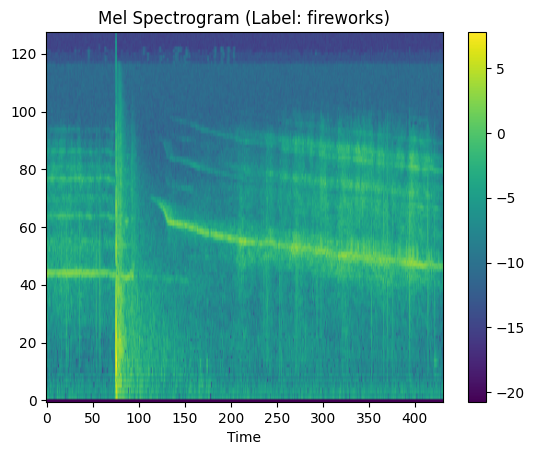

In [17]:
# Raw Waveform Augmentation
def waveform_data_augmentation(raw_waveform):
  raw_waveform = raw_waveform + 0.005 * torch.rand_like(raw_waveform)
  gain = torch.empty(1).uniform_(0.6, 1.4).item()
  raw_waveform = raw_waveform * gain
  shift = torch.randint(-2000, 2000, (1,)).item()
  raw_waveform = torch.roll(raw_waveform, shifts=shift)
  return raw_waveform


# Spectrogram Data Augmentation
spectrogram_data_augmentation = torch.nn.Sequential(
  spec.FrequencyMasking(freq_mask_param=8),
  spec.TimeMasking(time_mask_param=25)
)

# Create PyTorch Datasets
class ESC50TorchDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, spec_transform=None, raw_transform=None):
        self.ds = hf_dataset
        self.spec_transform = spec_transform
        self.raw_transform = raw_transform
        self.mel_spec = spec.MelSpectrogram( # convert to spectrogram (parameters are subject to change)
            sample_rate=44100,
            n_fft=1024,
            hop_length=512,
            n_mels=128
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        waveform = torch.tensor(sample["audio"]["array"], dtype=torch.float32) # torch tensor conversion
        if self.raw_transform:
          waveform = self.raw_transform(waveform)
        if waveform.ndim == 1:
            waveform = waveform.unsqueeze(0)
        mel_spec = self.mel_spec(waveform) # convert to spectrogram
        mel_spec = torch.log(mel_spec + 1e-9)
        target = torch.tensor(sample["target"], dtype=torch.long)

        if self.spec_transform:
          mel_spec = self.spec_transform(mel_spec)

        return mel_spec, target

# Display a sample spectrogram from fold 1 for reference
sample_dataset = ESC50TorchDataset(total_set.filter(lambda x: x["fold"] == 1))
x, y = sample_dataset[132]
mel_spec = x[-1].numpy()
print(x.shape)


plt.figure()
plt.imshow(mel_spec, aspect='auto', origin='lower')
plt.title(f"Mel Spectrogram (Label: {esc50_labels[y]})")
plt.xlabel("Time")
plt.colorbar()
plt.show()


# Baseline Comparison w/ Simpler Approach (Logistic Regression)

In [46]:
# Logistic Regression with 5-Fold Cross Validation
lr_fold_accuracies = []

for test_fold in range(1, 6):
    train_data = total_set.filter(lambda x: x["fold"] != test_fold)
    test_data  = total_set.filter(lambda x: x["fold"] == test_fold)

    x_train = np.stack([s["array"] for s in train_data["audio"]])
    y_train = np.array(train_data["target"])
    x_test  = np.stack([s["array"] for s in test_data["audio"]])
    y_test  = np.array(test_data["target"])

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled  = scaler.transform(x_test)

    logistic_regression = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto")
    logistic_regression.fit(x_train_scaled, y_train)
    y_pred = logistic_regression.predict(x_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    lr_fold_accuracies.append(acc)
    print(f"Logistic Regression Fold {test_fold} Accuracy: {acc:.4f}")

print(f"\nLogistic Regression Mean Accuracy: {np.mean(lr_fold_accuracies):.4f} +/- {np.std(lr_fold_accuracies):.4f}")


Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Fold 1 Accuracy: 0.0400


Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Logistic Regression Fold 4 Accuracy: 0.0200


Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Fold 5 Accuracy: 0.0325

Logistic Regression Mean Accuracy: 0.0300 +/- 0.0076


# Higher Performing Baseline Comparison w/ BEATs Transformer Model

In [6]:
BEATs_model = BEATs(
    ckp_path="/content/models/BEATs_iter3_plus_AS2M_finetuned_on_AS2M_cpt2.pt",
    freeze=True
).to(device)

BEATs_model.eval()

train_data = total_set.filter(lambda x: x["fold"] != 5)
test_data  = total_set.filter(lambda x: x["fold"] == 5)

# Preprocessing
def preprocess(example):
    audio = example["audio"]
    waveform = torch.tensor(audio["array"]).float()
    sr = audio["sampling_rate"]

    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    return waveform, example["target"]

# Extract Embeddings w/ BEAT Instance
def extract_embedding(waveform):
    waveform = waveform.unsqueeze(0).to(device)  # [1, T]

    # SpeechBrain format: relative length, 1.0 = full waveform
    wav_lens = torch.tensor([1.0], device=device)

    with torch.no_grad():
        out = BEATs_model(waveform, wav_lens=wav_lens)

    if isinstance(out, tuple):
        out = out[0]

    if out.dim() == 3:
        out = out.mean(dim=1)

    return out.squeeze(0).cpu()

# Create Features
def build_features(data):
    X, y = [], []

    for example in tqdm(data):
        waveform, label = preprocess(example)
        emb = extract_embedding(waveform)

        X.append(emb)
        y.append(label)

    return torch.stack(X), torch.tensor(y)

print("Extracting features...")
X_train, y_train = build_features(train_data)
X_test, y_test = build_features(test_data)

# Classifier
input_dim = X_train.shape[1]
num_classes = 50

classifier = nn.Linear(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training On New Data
epochs = 50

for epoch in range(epochs):
    classifier.train()

    logits = classifier(X_train)
    loss = criterion(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    classifier.eval()
    with torch.no_grad():
        preds = classifier(X_test).argmax(dim=1)
        acc = (preds == y_test).float().mean().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Test Acc: {acc*100:.2f}%")

all_targets = []
all_predictions = []

# Model Evalutation
classifier.eval()
with torch.no_grad():
    preds = classifier(X_test).argmax(dim=1)

y_true = y_test.cpu().numpy()
y_pred = preds.cpu().numpy()

cm = confusion_matrix(all_targets, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esc50_labels)
fig, ax = plt.subplots(figsize=(15,15))
disp.plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=90)
plt.title("Confusion Matrix - Audio Classifier Pipeline (Fold 5 Test Set)")
plt.tight_layout()
plt.show()

print("\nFinal Accuracy:", accuracy_score(y_true, y_pred))


FileNotFoundError: Checkpoint file '/content/models/BEATs_iter3_plus_AS2M_finetuned_on_AS2M_cpt2.pt' does not exist.

# Custom CNN Model Implementation

In [9]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        # Input after padding: 1 x 448 x 128
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False)   # 448x128 -> 224x64
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1, bias=False)  # 224x64 -> 112x32
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn5 = nn.BatchNorm2d(256)

        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False)  # 112x32 -> 56x16
        self.bn6 = nn.BatchNorm2d(256)

        self.conv7 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn7 = nn.BatchNorm2d(256)

        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False)  # 56x16 -> 28x8
        self.bn8 = nn.BatchNorm2d(256)

        self.relu = nn.ReLU(inplace=True)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 4))

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256 * 4, num_classes)

    def forward(self, x):
        x = F.pad(x, (8,9,0,0), mode='replicate') # Add padding so spectr. is div by power of 2
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))

        x = self.relu(self.bn5(self.conv5(x)))
        x = self.relu(self.bn6(self.conv6(x)))

        x = self.relu(self.bn7(self.conv7(x)))
        x = self.relu(self.bn8(self.conv8(x)))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)
        x = self.fc(x)

        return x

# Pre-set Hyperparameters and Training Loop Function

In [11]:
# Hyperparameters
learning_rate = 0.00005
epochs_per_fold = 100
num_classes = 50



In [9]:
def CNNTrainingMethod(
    total_set,
    model_class,
    dataset_class,
    num_classes,
    device,
    learning_rate,
    epochs_per_fold,
    batch_size=64,
    weight_decay=2e-4,
    use_augmentation=False,
    spec_transform=None,
    raw_transform=None,
    run_name="Custom CNN",
    save_path=None
):
    fold_accuracies = []
    fold_f1_scores = []

    best_fold = None
    best_test_acc = 0.0
    best_test_f1 = 0.0

    best_training_loss = []
    best_training_accuracy = []
    best_validation_loss = []
    best_validation_accuracy = []

    best_model_state = None
    best_test_loader = None

    for test_fold in range(1, 6):
        print(f"\n{'='*60}")
        print(f"  {run_name} | Fold {test_fold} as TEST")
        print(f"{'='*60}")

        val_fold = (test_fold % 4) + 1

        train_data = total_set.filter(lambda x: x["fold"] != test_fold and x["fold"] != val_fold)
        val_data = total_set.filter(lambda x: x["fold"] == val_fold)
        test_data = total_set.filter(lambda x: x["fold"] == test_fold)

        if use_augmentation:
            train_ds_base = dataset_class(train_data)
            train_ds_aug = dataset_class(
                train_data,
                spec_transform=spec_transform,
                raw_transform=raw_transform
            )
            train_dataset = torch.utils.data.ConcatDataset([train_ds_base, train_ds_aug])
        else:
            train_dataset = dataset_class(train_data)

        val_dataset = dataset_class(val_data)
        test_dataset = dataset_class(test_data)

        training_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model = model_class(num_classes).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

        training_loss = []
        training_accuracy = []
        validation_loss = []
        validation_accuracy = []

        for epoch in range(epochs_per_fold):
            train_loss, train_acc = train_one_epoch(
                model, training_loader, criterion, optimizer, device
            )

            val_loss, val_acc = evaluate_one_epoch(
                model, validation_loader, criterion, device
            )

            training_loss.append(train_loss)
            training_accuracy.append(train_acc)
            validation_loss.append(val_loss)
            validation_accuracy.append(val_acc)

            print(
                f"Epoch [{epoch+1}/{epochs_per_fold}] | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
            )

        test_loss, test_acc, test_f1 = test_model(
            model, test_loader, criterion, device
        )

        fold_accuracies.append(test_acc)
        fold_f1_scores.append(test_f1)

        print(
            f"Fold {test_fold} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}% | "
            f"F1 Score: {test_f1:.4f}"
        )

        # Save best fold based on test accuracy
        if test_acc > best_test_acc:
            best_fold = test_fold
            best_test_acc = test_acc
            best_test_f1 = test_f1

            best_training_loss = training_loss
            best_training_accuracy = training_accuracy
            best_validation_loss = validation_loss
            best_validation_accuracy = validation_accuracy

            best_model_state = copy.deepcopy(model.state_dict())
            best_test_loader = test_loader

            if save_path is not None:
                torch.save(best_model_state, save_path)

    best_model = model_class(num_classes).to(device)
    best_model.load_state_dict(best_model_state)
    best_model.eval()

    print(
        f"\n{run_name} Mean Accuracy: "
        f"{np.mean(fold_accuracies):.2f}% +/- {np.std(fold_accuracies):.2f}%"
    )

    print(
        f"{run_name} Mean F1 Score: "
        f"{np.mean(fold_f1_scores):.4f} +/- {np.std(fold_f1_scores):.4f}"
    )

    print(
        f"\nBest Fold: {best_fold} | "
        f"Best Test Acc: {best_test_acc:.2f}% | "
        f"Best F1 Score: {best_test_f1:.4f}"
    )

    return {
        "fold_accuracies": fold_accuracies,
        "fold_f1_scores": fold_f1_scores,
        "best_fold": best_fold,
        "best_test_acc": best_test_acc,
        "best_test_f1": best_test_f1,
        "best_training_loss": best_training_loss,
        "best_training_accuracy": best_training_accuracy,
        "best_validation_loss": best_validation_loss,
        "best_validation_accuracy": best_validation_accuracy,
        "best_model": best_model,
        "best_model_state": best_model_state,
        "best_test_loader": best_test_loader,
    }


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for data, targets in loader:
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item()
        total += targets.size(0)

    return running_loss / len(loader), 100 * correct / total


def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in loader:
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)

    return running_loss / len(loader), 100 * correct / total


def test_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for data, targets in loader:
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == targets).sum().item()
            total += targets.size(0)

            all_predictions.append(predicted.cpu())
            all_targets.append(targets.cpu())

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    all_predictions = torch.cat(all_predictions).numpy()
    all_targets = torch.cat(all_targets).numpy()

    f1 = f1_score(all_targets, all_predictions, average="macro")

    return avg_loss, accuracy, f1

# CNN Model Results w/o Data Augmentation

In [9]:
# Training and Testing Loop for the Standard Model Before Data Augmentation
standard_model_results = CNNTrainingMethod(
    total_set=total_set,
    model_class=CNN,
    dataset_class=ESC50TorchDataset,
    num_classes=num_classes,
    device=device,
    learning_rate=learning_rate,
    epochs_per_fold=epochs_per_fold,
    weight_decay=2e-4,
    use_augmentation=False,
    spec_transform=None,
    raw_transform=None,
    run_name="Standard CNN",
    save_path="/content/drive/MyDrive/before_augmentation.pth"
)


  Standard CNN | Fold 1 as TEST


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Epoch [1/100] | Train Loss: 3.8293 | Train Acc: 4.83% | Val Loss: 3.9004 | Val Acc: 2.00%
Epoch [2/100] | Train Loss: 3.5882 | Train Acc: 11.08% | Val Loss: 3.6583 | Val Acc: 8.75%
Epoch [3/100] | Train Loss: 3.4774 | Train Acc: 13.25% | Val Loss: 3.4789 | Val Acc: 13.25%
Epoch [4/100] | Train Loss: 3.3227 | Train Acc: 17.00% | Val Loss: 3.3498 | Val Acc: 14.50%
Epoch [5/100] | Train Loss: 3.2349 | Train Acc: 18.75% | Val Loss: 3.2451 | Val Acc: 18.25%
Epoch [6/100] | Train Loss: 3.1123 | Train Acc: 22.75% | Val Loss: 3.2035 | Val Acc: 21.75%
Epoch [7/100] | Train Loss: 3.0187 | Train Acc: 26.50% | Val Loss: 3.1144 | Val Acc: 24.50%
Epoch [8/100] | Train Loss: 2.9147 | Train Acc: 31.25% | Val Loss: 3.0685 | Val Acc: 27.00%
Epoch [9/100] | Train Loss: 2.8410 | Train Acc: 31.17% | Val Loss: 2.9954 | Val Acc: 28.00%
Epoch [10/100] | Train Loss: 2.7503 | Train Acc: 35.17% | Val Loss: 2.9668 | Val Acc: 28.00%
Epoch [11/100] | Train Loss: 2.6959 | Train Acc: 37.33% | Val Loss: 2.9055 | Val A

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Epoch [1/100] | Train Loss: 3.8348 | Train Acc: 4.17% | Val Loss: 3.8773 | Val Acc: 4.25%
Epoch [2/100] | Train Loss: 3.6001 | Train Acc: 8.75% | Val Loss: 3.5988 | Val Acc: 12.00%
Epoch [3/100] | Train Loss: 3.4476 | Train Acc: 11.67% | Val Loss: 3.4156 | Val Acc: 15.50%
Epoch [4/100] | Train Loss: 3.3471 | Train Acc: 14.17% | Val Loss: 3.3231 | Val Acc: 16.75%
Epoch [5/100] | Train Loss: 3.2614 | Train Acc: 15.58% | Val Loss: 3.2309 | Val Acc: 18.25%
Epoch [6/100] | Train Loss: 3.1590 | Train Acc: 21.17% | Val Loss: 3.1327 | Val Acc: 21.50%
Epoch [7/100] | Train Loss: 3.0594 | Train Acc: 23.33% | Val Loss: 3.0549 | Val Acc: 25.75%
Epoch [8/100] | Train Loss: 2.9709 | Train Acc: 26.83% | Val Loss: 3.0059 | Val Acc: 29.50%
Epoch [9/100] | Train Loss: 2.8981 | Train Acc: 29.33% | Val Loss: 2.9507 | Val Acc: 29.25%
Epoch [10/100] | Train Loss: 2.8328 | Train Acc: 31.25% | Val Loss: 2.9110 | Val Acc: 30.00%
Epoch [11/100] | Train Loss: 2.7660 | Train Acc: 33.75% | Val Loss: 2.8378 | Val A

...

Epoch [1/100] | Train Loss: 3.8502 | Train Acc: 4.33% | Val Loss: 3.9083 | Val Acc: 2.00%
Epoch [2/100] | Train Loss: 3.6160 | Train Acc: 10.17% | Val Loss: 3.6525 | Val Acc: 10.00%
Epoch [3/100] | Train Loss: 3.4787 | Train Acc: 12.08% | Val Loss: 3.4719 | Val Acc: 13.25%
Epoch [4/100] | Train Loss: 3.3624 | Train Acc: 14.67% | Val Loss: 3.3872 | Val Acc: 16.75%
Epoch [5/100] | Train Loss: 3.2945 | Train Acc: 16.25% | Val Loss: 3.2926 | Val Acc: 15.50%
Epoch [6/100] | Train Loss: 3.1820 | Train Acc: 20.08% | Val Loss: 3.2234 | Val Acc: 20.50%
Epoch [7/100] | Train Loss: 3.0855 | Train Acc: 23.67% | Val Loss: 3.1628 | Val Acc: 20.00%
Epoch [8/100] | Train Loss: 2.9992 | Train Acc: 26.92% | Val Loss: 3.0737 | Val Acc: 22.25%
Epoch [9/100] | Train Loss: 2.9133 | Train Acc: 28.33% | Val Loss: 3.0550 | Val Acc: 25.25%
Epoch [10/100] | Train Loss: 2.8347 | Train Acc: 32.92% | Val Loss: 2.9568 | Val Acc: 25.00%
Epoch [11/100] | Train Loss: 2.7355 | Train Acc: 36.83% | Val Loss: 2.9276 | Val 

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Epoch [1/100] | Train Loss: 3.8327 | Train Acc: 4.17% | Val Loss: 3.8853 | Val Acc: 3.00%
Epoch [2/100] | Train Loss: 3.5571 | Train Acc: 9.83% | Val Loss: 3.6294 | Val Acc: 10.50%
Epoch [3/100] | Train Loss: 3.3858 | Train Acc: 13.67% | Val Loss: 3.4142 | Val Acc: 14.50%
Epoch [4/100] | Train Loss: 3.3046 | Train Acc: 16.67% | Val Loss: 3.3392 | Val Acc: 16.75%
Epoch [5/100] | Train Loss: 3.2081 | Train Acc: 17.08% | Val Loss: 3.2520 | Val Acc: 17.50%
Epoch [6/100] | Train Loss: 3.0956 | Train Acc: 22.08% | Val Loss: 3.1615 | Val Acc: 18.00%
Epoch [7/100] | Train Loss: 3.0109 | Train Acc: 26.08% | Val Loss: 3.1106 | Val Acc: 22.00%
Epoch [8/100] | Train Loss: 2.9323 | Train Acc: 27.17% | Val Loss: 3.0575 | Val Acc: 26.00%
Epoch [9/100] | Train Loss: 2.8382 | Train Acc: 30.67% | Val Loss: 2.9987 | Val Acc: 26.50%
Epoch [10/100] | Train Loss: 2.7771 | Train Acc: 31.08% | Val Loss: 2.9460 | Val Acc: 29.75%
Epoch [11/100] | Train Loss: 2.7087 | Train Acc: 33.25% | Val Loss: 2.9361 | Val A

KeyError: 'final_training_loss'

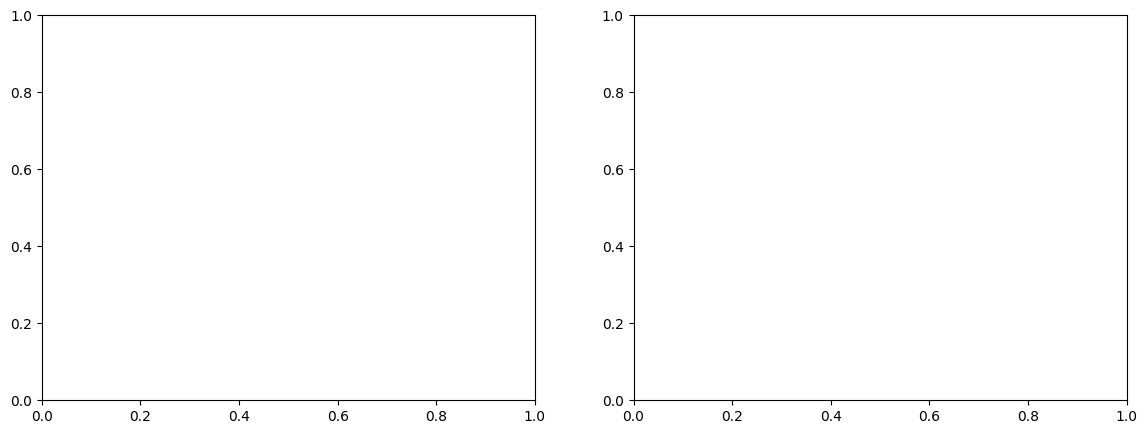

In [11]:
# Print Accuracy and Loss for Validation and Training sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs_per_fold+1), standard_model_results['best_training_loss'], label="Training")
ax1.plot(range(1, epochs_per_fold+1), standard_model_results['best_validation_loss'], label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss: Train vs. Validation")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, epochs_per_fold+1), standard_model_results['best_training_accuracy'], label="Training")
ax2.plot(range(1, epochs_per_fold+1), standard_model_results['best_validation_accuracy'], label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy: Train vs. Validation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Ablation Comparison | Improving Performance Through Data Augmentation

In [11]:
# After Augmentation
augmentation_model_results = CNNTrainingMethod(
    total_set=total_set,
    model_class=CNN,
    dataset_class=ESC50TorchDataset,
    num_classes=num_classes,
    device=device,
    learning_rate=learning_rate,
    epochs_per_fold=epochs_per_fold,
    weight_decay=2e-4,
    use_augmentation=True,
    spec_transform=spectrogram_data_augmentation,
    raw_transform=waveform_data_augmentation,
    run_name="Augmented CNN",
    save_path="/content/drive/MyDrive/after_augmentation.pth"
)


  Augmented CNN | Fold 1 as TEST


Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


...

Epoch [1/100] | Train Loss: 3.7762 | Train Acc: 5.46% | Val Loss: 3.6405 | Val Acc: 8.00%
Epoch [2/100] | Train Loss: 3.4839 | Train Acc: 12.50% | Val Loss: 3.3235 | Val Acc: 15.75%
Epoch [3/100] | Train Loss: 3.2915 | Train Acc: 17.25% | Val Loss: 3.2064 | Val Acc: 20.25%
Epoch [4/100] | Train Loss: 3.1361 | Train Acc: 21.71% | Val Loss: 3.0890 | Val Acc: 21.00%
Epoch [5/100] | Train Loss: 3.0009 | Train Acc: 24.88% | Val Loss: 2.9967 | Val Acc: 26.50%
Epoch [6/100] | Train Loss: 2.8711 | Train Acc: 28.58% | Val Loss: 2.8635 | Val Acc: 27.50%
Epoch [7/100] | Train Loss: 2.7572 | Train Acc: 32.38% | Val Loss: 2.7598 | Val Acc: 31.50%
Epoch [8/100] | Train Loss: 2.6190 | Train Acc: 35.46% | Val Loss: 2.7386 | Val Acc: 31.50%
Epoch [9/100] | Train Loss: 2.5350 | Train Acc: 38.83% | Val Loss: 2.5797 | Val Acc: 38.75%
Epoch [10/100] | Train Loss: 2.4309 | Train Acc: 41.25% | Val Loss: 2.4965 | Val Acc: 40.00%
Epoch [11/100] | Train Loss: 2.3162 | Train Acc: 46.17% | Val Loss: 2.4256 | Val 

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


Epoch [1/100] | Train Loss: 3.7647 | Train Acc: 4.92% | Val Loss: 3.5807 | Val Acc: 9.75%
Epoch [2/100] | Train Loss: 3.4655 | Train Acc: 11.96% | Val Loss: 3.3261 | Val Acc: 14.75%
Epoch [3/100] | Train Loss: 3.2910 | Train Acc: 15.62% | Val Loss: 3.2247 | Val Acc: 14.25%
Epoch [4/100] | Train Loss: 3.1319 | Train Acc: 19.75% | Val Loss: 3.1089 | Val Acc: 19.00%
Epoch [5/100] | Train Loss: 3.0074 | Train Acc: 23.08% | Val Loss: 2.9936 | Val Acc: 20.50%
Epoch [6/100] | Train Loss: 2.8811 | Train Acc: 26.67% | Val Loss: 2.9813 | Val Acc: 25.75%
Epoch [7/100] | Train Loss: 2.7654 | Train Acc: 30.67% | Val Loss: 2.8264 | Val Acc: 31.50%
Epoch [8/100] | Train Loss: 2.6288 | Train Acc: 36.04% | Val Loss: 2.7513 | Val Acc: 33.50%
Epoch [9/100] | Train Loss: 2.5222 | Train Acc: 38.92% | Val Loss: 2.6098 | Val Acc: 40.00%
Epoch [10/100] | Train Loss: 2.4131 | Train Acc: 41.62% | Val Loss: 2.5230 | Val Acc: 39.00%
Epoch [11/100] | Train Loss: 2.3343 | Train Acc: 45.17% | Val Loss: 2.4361 | Val 

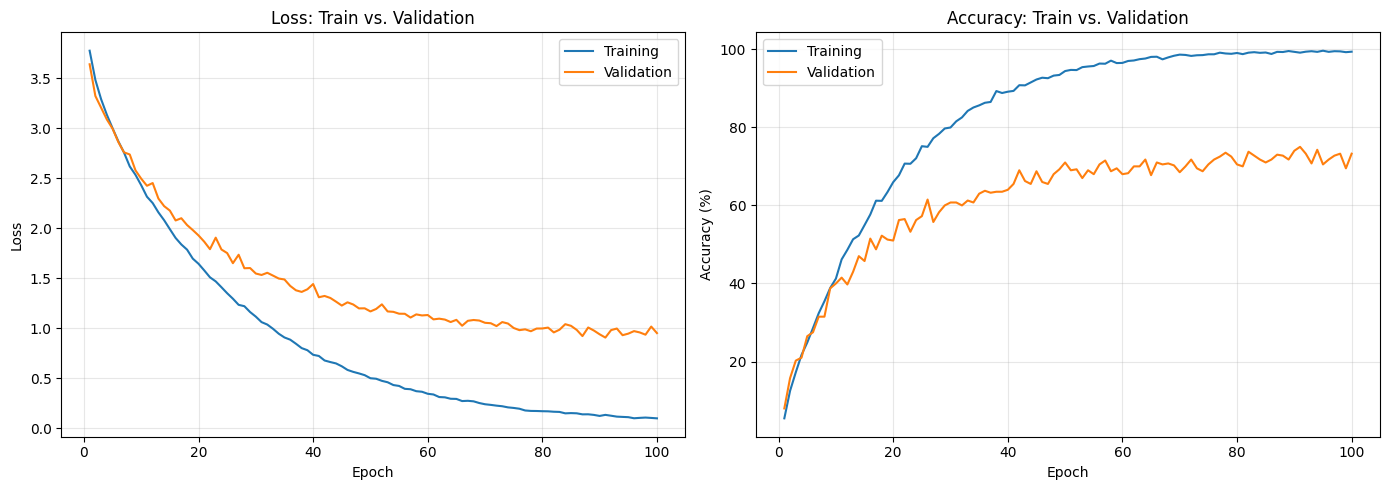

In [12]:
# Print Accuracy and Loss for Validation and Training sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs_per_fold+1), augmentation_model_results['best_training_loss'], label="Training")
ax1.plot(range(1, epochs_per_fold+1), augmentation_model_results['best_validation_loss'], label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss: Train vs. Validation")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, epochs_per_fold+1), augmentation_model_results['best_training_accuracy'], label="Training")
ax2.plot(range(1, epochs_per_fold+1), augmentation_model_results['best_validation_accuracy'], label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy: Train vs. Validation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Loading Persistently Saved Model | Confusion Matrix & Example Sample Predictions

In [44]:
# Final Persistent Model Evaluation (Produces Confusion Matrix & Sample Predictions)
def final_model_evaluation(model, dataset, device):

    all_predictions = []
    all_targets = []

    # Confusion Matrix
    with torch.no_grad():
        for data, targets in dataset:
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_predictions)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=esc50_labels
    )

    fig, ax = plt.subplots(figsize=(15, 15))
    disp.plot(
        ax=ax,
        cmap="Greens",
        colorbar=False,
        xticks_rotation=90
    )
    plt.title("Confusion Matrix - Augmented CNN")
    plt.tight_layout()
    plt.show()

    # Example Test Predictions
    dataiter = iter(dataset)
    data, labels = next(dataiter)
    data_dev = data.to(device)
    with torch.no_grad():
        outputs = model(data_dev)
        _, predicted = torch.max(outputs, 1)

    fig, axes = plt.subplots(2, 8, figsize=(16, 5))

    for i in range(16):
        ax = axes[i // 8][i % 8]

        img = data[i]
        ax.imshow(img[-1].numpy(), aspect="auto")

        pred = predicted[i].item()
        true = labels[i].item()

        color = "green" if pred == true else "red"

        ax.set_title(
            f"P:{esc50_labels[pred]}\nT:{esc50_labels[true]}",
            color=color,
            fontsize=8
        )
        ax.axis("off")

    plt.suptitle("Test predictions (green = correct, red = wrong)", y=1.02)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


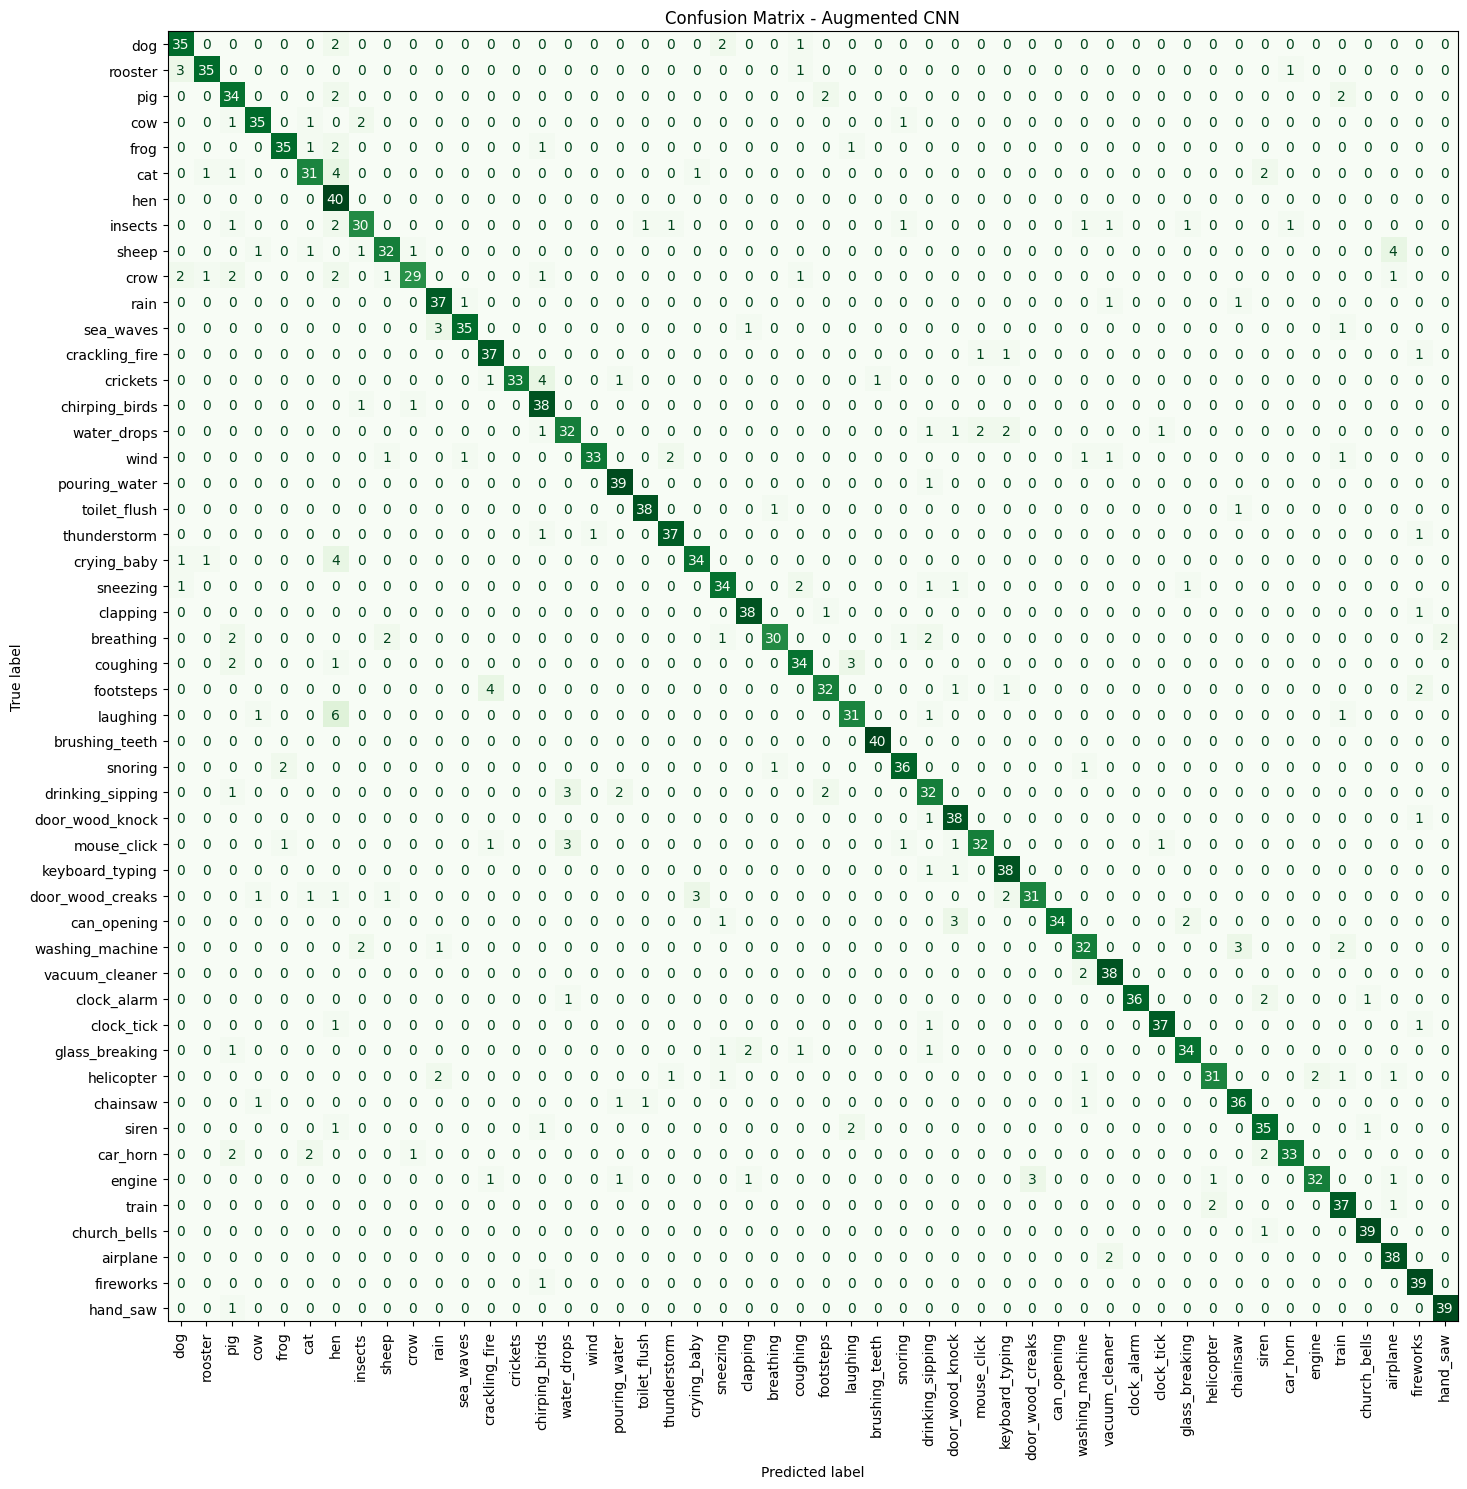

Model Accuracy: 87.25%


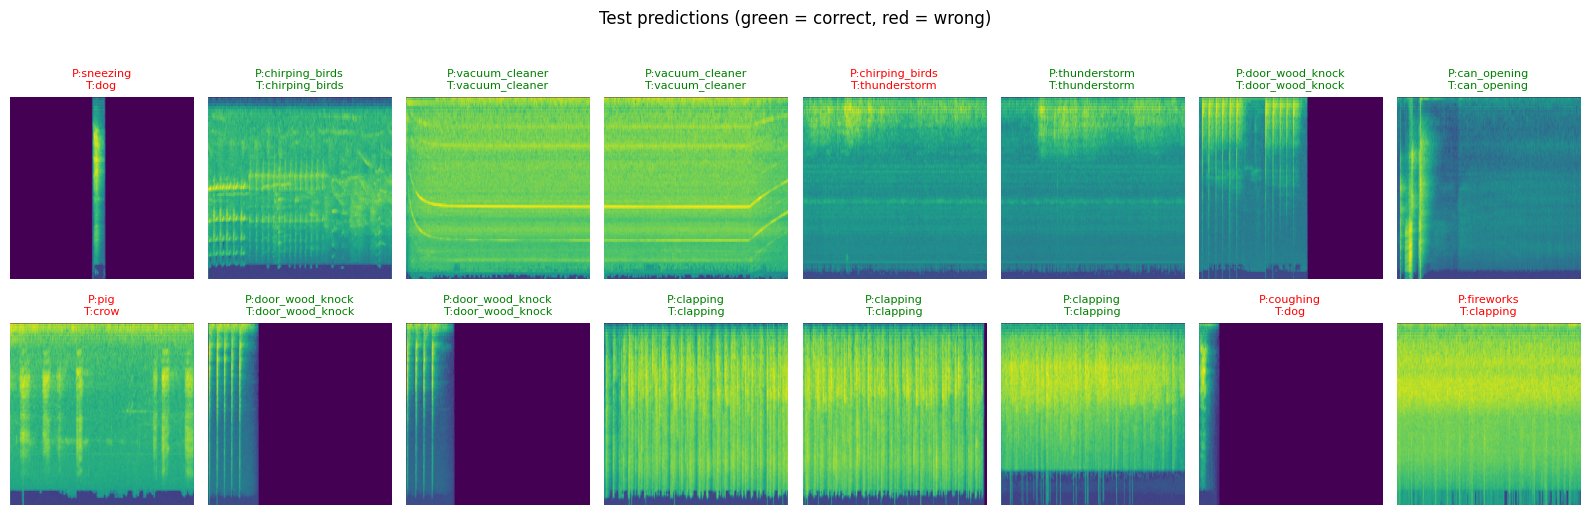

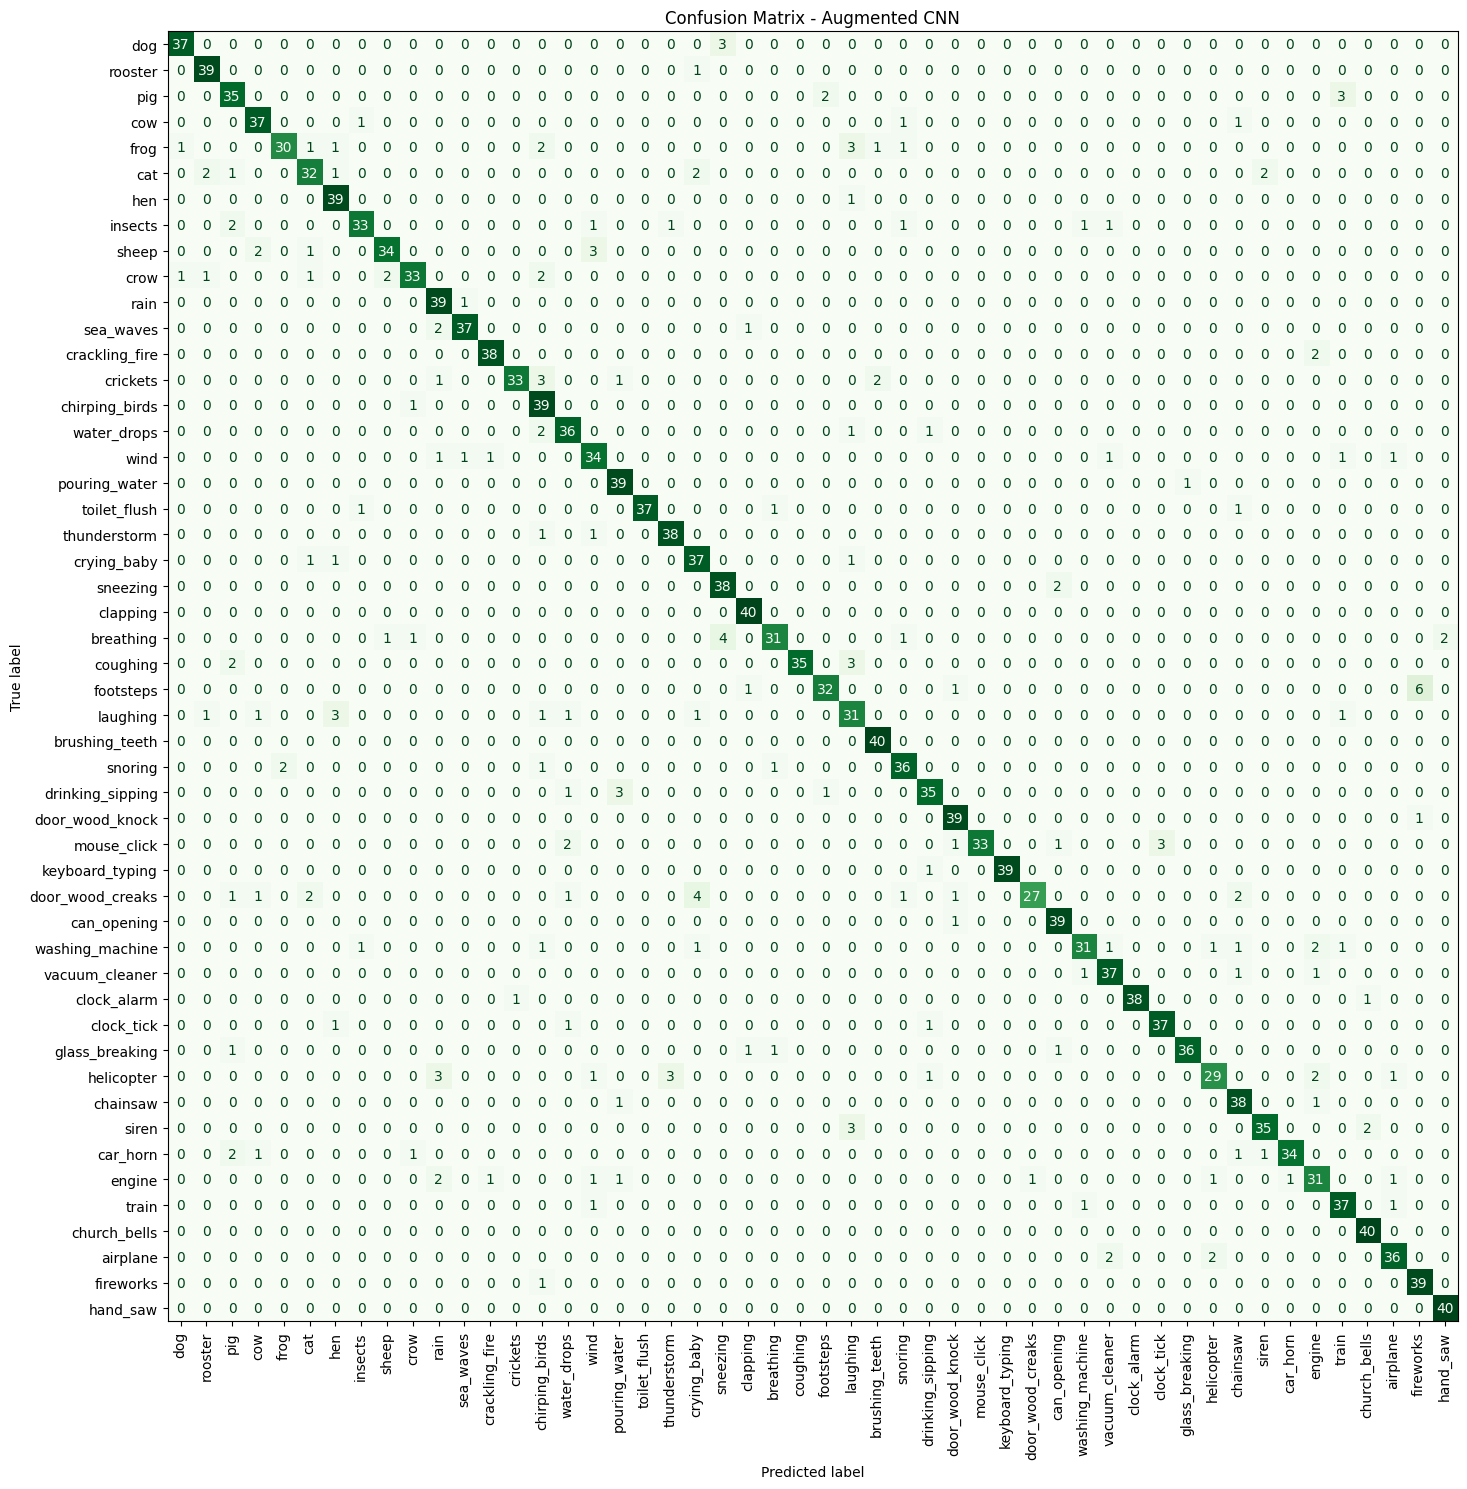

Model Accuracy: 89.45%


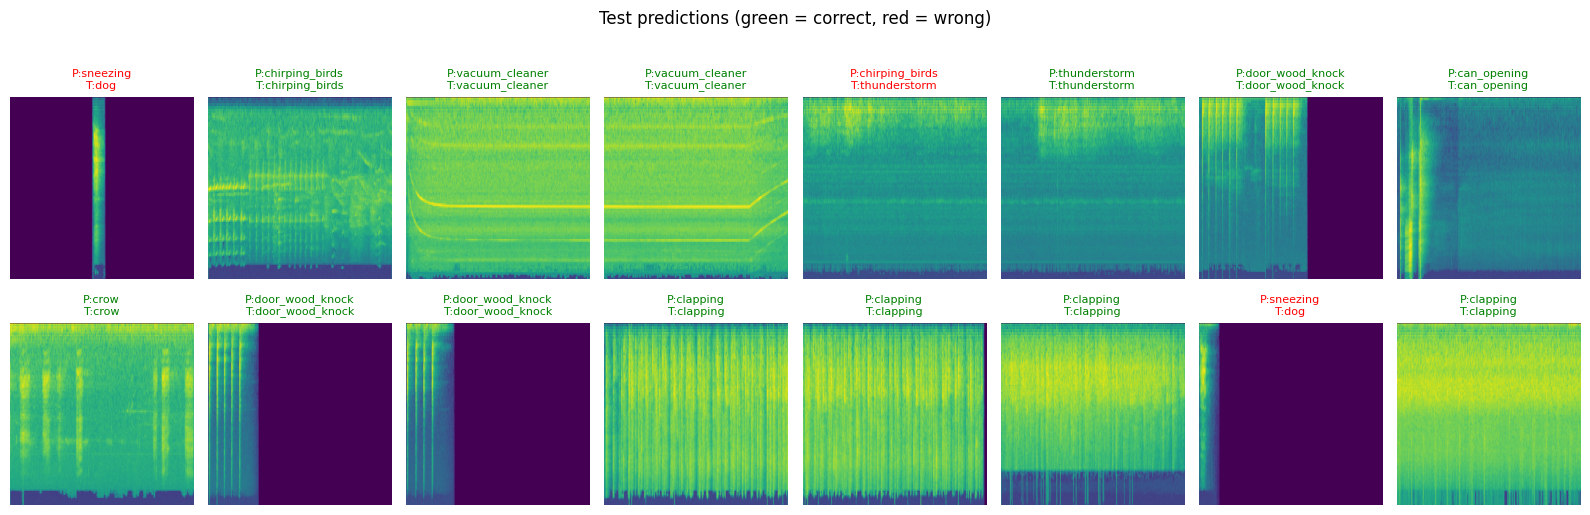

In [48]:
# Define Model and Load Persistent Weights From Directory
before_model = CNN(num_classes=num_classes)
before_model.load_state_dict(torch.load("/content/drive/MyDrive/before_augmentation.pth"))
before_model = before_model.to(device)
before_model.eval()

# Define Model and Load Persistent Weights From Directory
after_model = CNN(num_classes=num_classes)
after_model.load_state_dict(torch.load("/content/drive/MyDrive/after_augmentation.pth"))
after_model = after_model.to(device)
after_model.eval()

# Set Up Dataset
full_set_eval = ESC50TorchDataset(total_set)
full_set_eval = DataLoader(full_set_eval, batch_size=64)

final_model_evaluation(before_model, full_set_eval, device)
final_model_evaluation(after_model, full_set_eval, device)